In [2]:
import torch, os, pickle, math
import os.path as osp
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))

if torch.cuda.is_available() and torch.cuda.device_count()>=1:
    device = 'cuda'
else:
    device = 'cpu'

# Connecting the optical and IR

Galaxies are often modeled as independent components, each emitting in distinct wavelength ranges. This assumption is a result of the assumption that the different physical components, which have different spectral signatures, are only weakly correlated. However, this assumption overlooks the deep, underlying physical couplings between components. 

By leveraging these couplings, we can predict IR photometry directly from optical spectra with remarkable accuracy. This capability is transformative for our understanding of galaxies, because it demonstrates that the different physical components of galaxies are in fact **extremely tightly coupled**.

Traditional spectrum (SED) fitting models struggle to capture these cross-wavelength relationships, exactly because they ignore the physical relations that drive this coherent picture of galaxy evolution.

With the wealth of optical spectra, and upcoming IR photometry, available from large-scale surveys, this approach opens new avenues for galaxy evolution studies. 

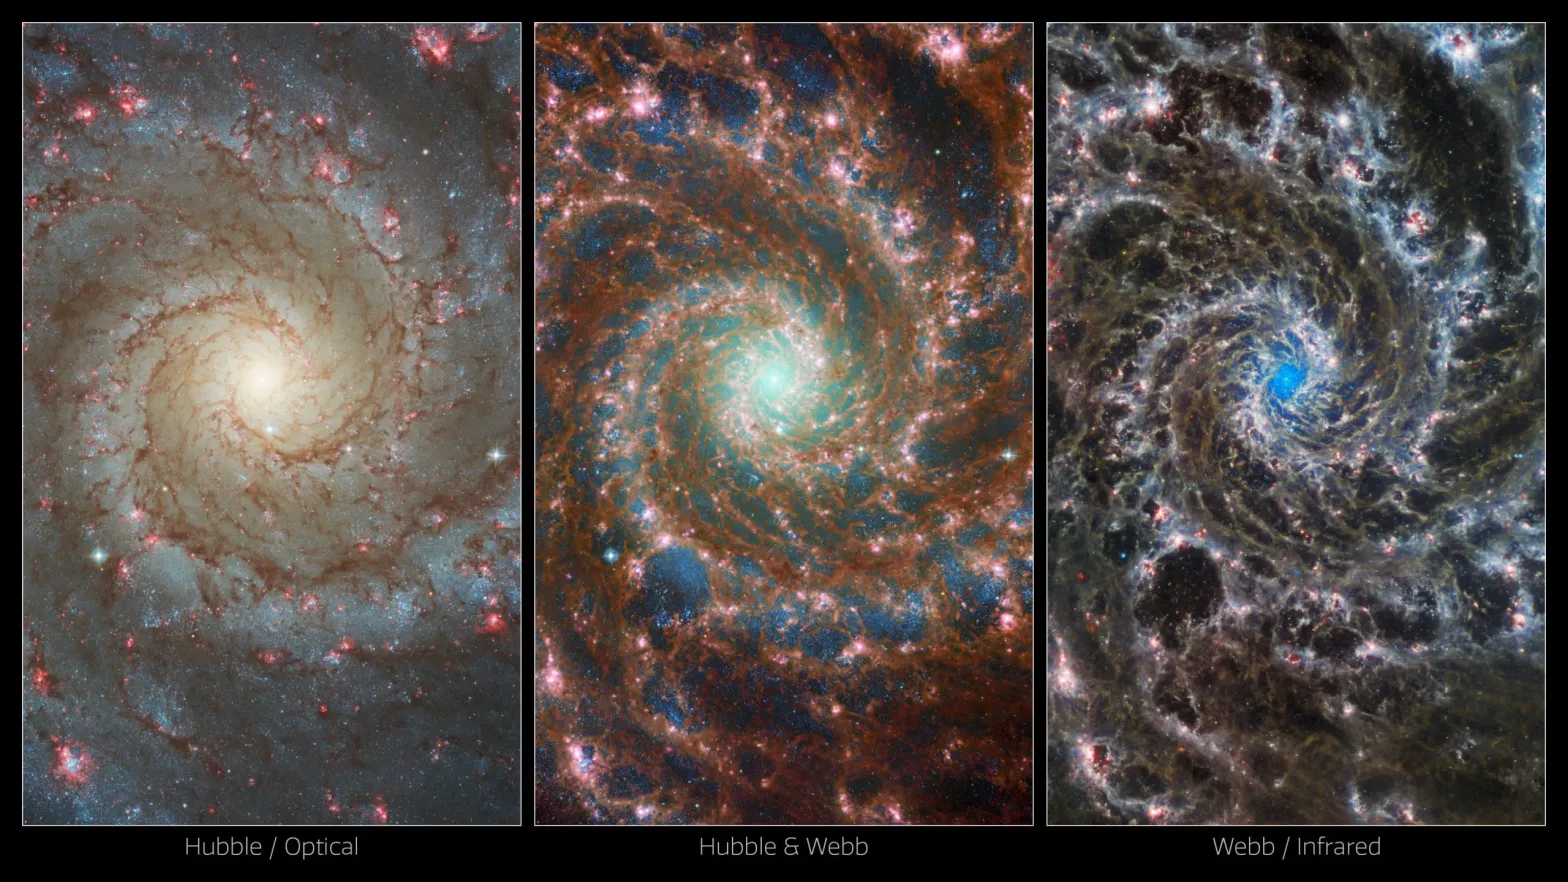

#### A demonstration of a galaxy imaged in both the optical and IR (credit: NASA). Some correlations are obvious, but predicting one from the other was an unsettled question until now.

# Predicting WISE Photometry from SDSS Optical Spectra Using the ``spender`` Autoencoder

This notebook demonstrates the process of predicting WISE photometry from optical spectra utilizing the ``spender`` autoencoder, as detailed in [Melchior et al. 2022](https://arxiv.org/abs/2211.07890) and [Liang et al. 2023](https://arxiv.org/abs/2302.02496). The notebook is divided into two main sections:

1. **Autoencoding Optical Spectra**: This section illustrates how the ``spender`` autoencoder processes and compresses optical spectra into a latent representation. [Click here for the auto-encoding step only.](#autoencoding-optical-spectra)


2. **Predicting WISE Photometry**: Building upon the autoencoded spectra, this section demonstrates the methodology to predict WISE photometric measurements. [Click here to skip the auto-encoding step.](#predicting-wise-photometry)

*Note*: As always with ML, the results may not fully replicate the findings of Jespersen et al. 2025, but this notebook should effectively demonstrate the method.

### Let's get started!

<a id="autoencoding-optical-spectra"></a>
## Autoencoding Optical Spectra with ``spender``

This step is not treated extensively in the paper, but since it makes a big difference for the way that the code works, we include it here. It is also just cool.

The Princeton Astro Data Group has a lot of pre-trained models, so choose the one that fits you!

Here we pick the one that was trained on SDSS-II.

In [3]:
import spender # install with < pip install spender >
# show list of pretrained models
print(spender.hub.list())

# print out details for SDSS model from paper II
print(spender.hub.help('sdss_II')) 

# load instrument and spectrum model from the hub
sdss, model = spender.hub.load('sdss_II', map_location=torch.device(device))

# if your machine does not have GPUs, specify the device
from accelerate import Accelerator
accelerator = Accelerator(mixed_precision='fp16')
sdss, model = spender.hub.load('sdss_II', map_location=accelerator.device)

['desi_edr_galaxy', 'desi_edr_galaxy_flow', 'desi_edr_star', 'desi_edr_star_flow', 'sdss_I', 'sdss_II', 'sdss_I_superres']
Spectrum Autoencoder model for the SDSS main galaxy sample.

    This model has S=6 latents and a restframe resolution R=7000 for a maximum redshift of z_max=0.5.
    It has been trained with fidelity, similarity, and consistency losses to provide a redshift-invariant latent space.

    See spender papers for details:
        Liang at al. (2023): arXiv:2302.02496
        Melchior et al. (2022): arXiv:2211.07890
    


In [4]:
## let's make sure the model is on the GPU if availiable
if not next(model.parameters()).is_cuda and device == 'cuda':
    model = model.to(torch.device('cuda'))

We have crossmatched SDSS optical spectra with WISE photometry. The things to care about for the autoencoding step are

1. The **normalized** spectra.
2. the redshifts (z).
3. The normalization (norm). This is just a simply multiplicative factor.

Other things included are
- The weights (inverse variances) which effectively mask out sky-lines as well as having the statistical error. These are only used for training, but they're in our data file.
- The redshift error (zerr)
- The spectrum ID, ``specid``, in ``[plate, MJD, fiberID]`` format
- The wise photometry and errors (wise)

In [5]:
path = osp.expanduser('data')
save_path = path
files = os.listdir(save_path)
files = [f for f in files if 'sdss' not in f]
files = files[:1]

print(save_path+files[0])

specs = []
weights = []
zs = []
norms = []
wises = []
for f in files:
    spec, weight, z, specid, norm, zerr, wise = pickle.load(open(os.path.join(save_path, f), "rb"))
    specs.append(spec)
    weights.append(weight)
    
    zs.append(z)
    norms.append(norm)        
    wises.append(wise)

specs = np.vstack(specs)
weights = np.vstack(weights)

wises = np.vstack(wises)
zs = np.hstack(zs)
norms = np.hstack(norms)

dataWISEvariable_59.pkl


/home/faculty/dmk333/miniforge3/envs/astronomy/lib/python3.11/site-packages/torch/storage.py:414: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(io.BytesIO(

### Now we're ready to go!
Because the spectra are already normalized, I can go ahead and just throw them into and get some latent variables.

In [6]:
latents = model.encoder(torch.tensor(specs[:10], device = torch.device(device)))
latents

tensor([[-0.3171,  0.0726,  0.5567,  0.4574,  0.4019, -0.4252],
        [ 0.7361,  0.3284, -0.2020, -1.2964, -0.4381,  0.4746],
        [-0.2742,  0.0693,  0.5189,  0.4114,  0.3660, -0.3794],
        [ 0.3605,  0.0699, -0.0568, -0.3904, -0.1739,  0.0873],
        [-0.2836,  0.0666,  0.5284,  0.4225,  0.3834, -0.3981],
        [-0.2492,  0.0568,  0.4816,  0.3765,  0.3409, -0.3604],
        [-0.2459,  0.0846,  0.5280,  0.3116,  0.3493, -0.3843],
        [ 0.0263,  0.1319,  0.4000, -0.1184,  0.1679, -0.2339],
        [ 0.1935,  0.1161,  0.2029, -0.2713,  0.0165, -0.1055],
        [ 0.8542,  0.3479, -0.3853, -1.4715, -0.5763,  0.6364]],
       device='cuda:0', grad_fn=<AddmmBackward0>)

Now we have some latents! Below is a demonstration of reconstructing spectra from the latents at the original/various redshifts, try playing with it a bit, it's a lot of fun seeing how the model extrapolates beyond the original observed wavelengths.

Of course, the model is traine at z = [0-0.5], so if you put z1 = 2, you'll get nonsense out.

In [7]:
# let's add some nice plotting stuff
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)
plt.rcParams["figure.facecolor"] = "white"
#plt.rc("text", usetex=True)
plt.rcParams['text.usetex'] = False
plt.rc("font", family="serif",size= 28)
plt.rc("axes", linewidth=1.5)
plt.rc("axes", labelsize=28)
plt.rc("xtick", labelsize=24, direction="in")
plt.rc("ytick", labelsize=24, direction="in")
plt.rc("xtick", top=True)
plt.rc("ytick", right=True)
plt.rc("xtick.minor", visible=True)
plt.rc("ytick.minor", visible=True)
plt.rc("xtick.major",size=13, pad=4)
plt.rc("xtick.minor",size=7, pad=4)
plt.rc("ytick.major",size=13)
plt.rc("ytick.minor",size=7)
plt.rc("legend", fontsize=22)

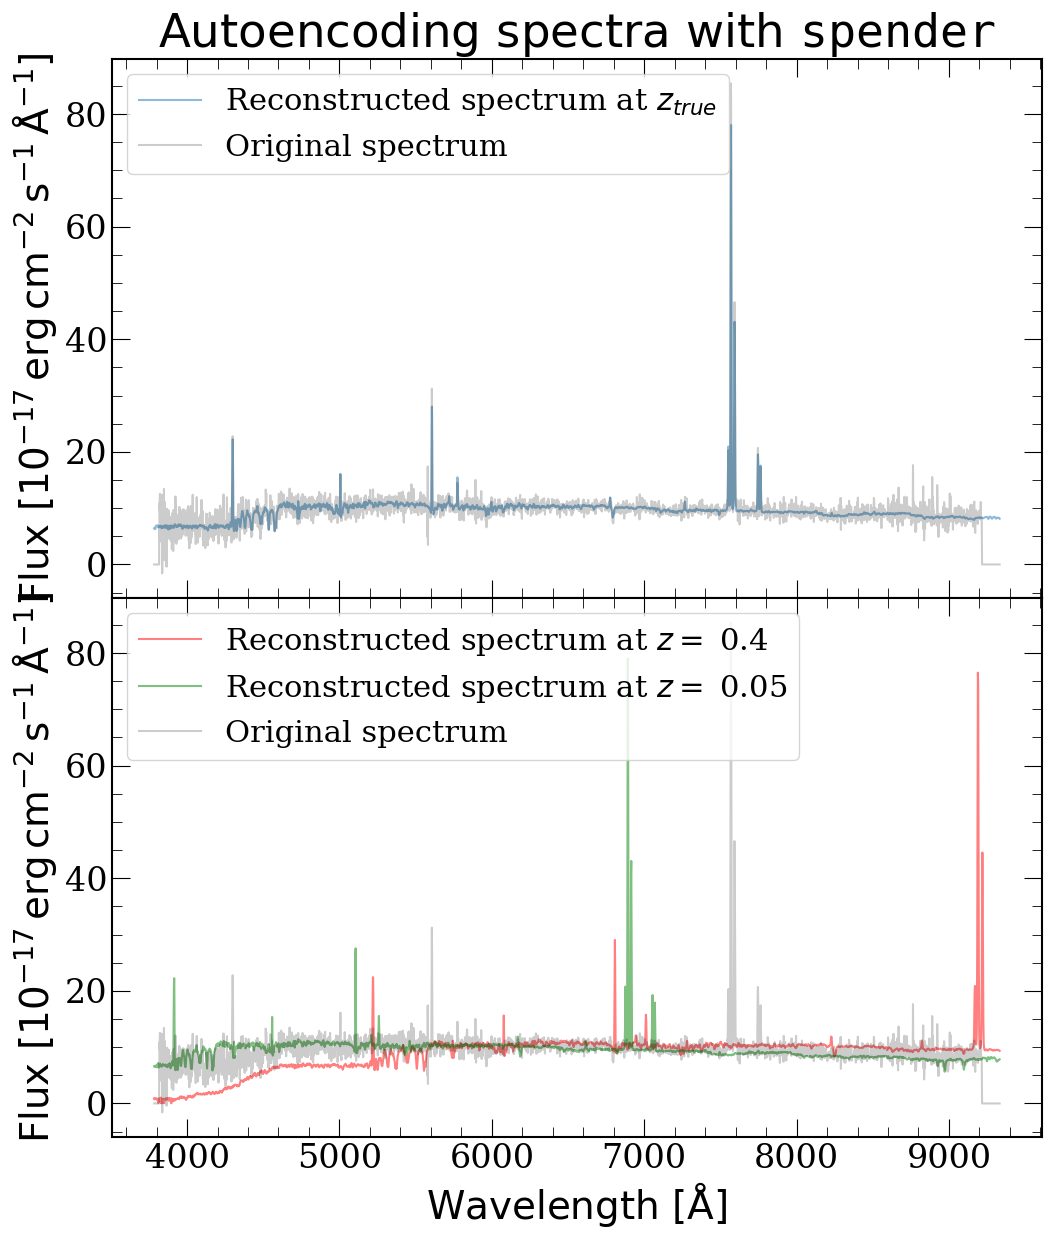

In [8]:
# wavelength in Å
wave_obs = 10 ** np.arange(3.578, 3.97, 0.0001)

# index for spectrum, change within 0-9 as you please
j = 1

# redhsift to reconstruct at
z1 = 0.4
z2 = 0.05
fig, ax = plt.subplots(figsize = (12,14), nrows = 2)
plt.subplots_adjust(hspace = 0)

s0 = specs[j]
lat = model.encoder(torch.tensor(np.vstack([s0]),  device = accelerator.device))
s = model.decoder(lat, instrument = sdss, z = torch.tensor([zs[j]], device = accelerator.device))

ax[0].plot(wave_obs, s.cpu().detach().numpy().T*norms[j], alpha = 0.5, label = r'Reconstructed spectrum at $z_{true}$')
ax[0].plot(wave_obs, s0*norms[j], 'k-', alpha = 0.2, label = 'Original spectrum')

s = model.decoder(lat, instrument = sdss, z = torch.tensor([z1], device = accelerator.device))
ax[1].plot(wave_obs, s.cpu().detach().numpy().T*norms[j], 'r-', alpha = 0.5, label = r'Reconstructed spectrum at $z = $'+f' {z1}')

s = model.decoder(lat, instrument = sdss, z = torch.tensor([z2], device = accelerator.device))
ax[1].plot(wave_obs, s.cpu().detach().numpy().T*norms[j], 'g-', alpha = 0.5, label = r'Reconstructed spectrum at $z = $'+f' {z2}')

ax[1].plot(wave_obs, s0*norms[j], 'k-', alpha = 0.2, label = 'Original spectrum')

for a in ax:
    a.legend()
    a.set(ylabel = r'$\mathrm{Flux~[10^{-17}\,erg\,cm^{-2}\,s^{-1}\,Å^{-1}]}$')

ax[0].set(title = r'$\mathrm{Autoencoding~spectra~with~}\mathtt{spender}$')
ax[1].set(xlabel = r'$\mathrm{Wavelength~[Å]}$')
fig

The main thing to notice here, is the models ability to accurately extrapolate beyond the wavelength range of the spectrum! 

This was the basis for the belief that the latents could be used to extrapolate even further!

---- But now that we the autoencoder in place, let's predict some IR photometry ----

<a id="predicting-wise-photometry"></a>
## Predicting WISE photometry

Now that we have demonstrated how to autoencode the optical spectra, let's go from the spectra to the IR photometry.

In [9]:
import pandas as pd
# it was unfortunately necessary to split up the data to have it on github, so there's a 0/1 version of the files, combine them for best results. For the demo, half should do though!
wise_sdss_spender = pd.read_csv(os.path.join(path,'sdss_wise_cross_reg0.csv.gz'))

In [10]:
len(wise_sdss_spender)

252139

In [11]:
phot_cols = ['w1mpro',  'w2mpro',  'w3mpro', 'w4mpro']
sig_cols = ['w1sigmpro',  'w2sigmpro',  'w3sigmpro', 'w4sigmpro']

wise_phot = wise_sdss_spender[phot_cols]
wise_phot_sig = wise_sdss_spender[sig_cols]

spender_cols = ['spender_'+f'{i}' for i in range(6)]
spender_cols+=['Z']
spender_cols+=['reg']


spender_lat = wise_sdss_spender[spender_cols]

# Unmodified training

In [46]:
import torch
import torch.nn as nn
import accelerate
from torch.optim import Adam
from torch.utils.data import DataLoader, TensorDataset

# X_train, X_test, y_train, y_test = train_test_split(spender_lat[:N], wise_phot[['w1mpro', 'w2mpro', 'w3mpro', 'w4mpro']][:N], random_state=1)

N = len(spender_lat)

data_x = spender_lat[:N].to_numpy()

data_y = wise_phot[['w1mpro', 'w2mpro', 'w3mpro', 'w4mpro']][:N]
data_sig = wise_phot_sig[['w1sigmpro', 'w2sigmpro', 'w3sigmpro', 'w4sigmpro']][:N]

dat_y = np.concatenate((data_y, data_sig), axis = 1)

ids = np.arange(len(data_x))
np.random.shuffle(ids)
train_id = ids[:int(len(ids)*0.8)] #for a random train/test set
test_id = ids[int(len(ids)*0.8):] #for a random train/test set

all_data = TensorDataset(torch.Tensor(data_x), torch.Tensor(dat_y))

train_data = all_data[train_id]
test_data = all_data[test_id]

batch_size = 5120

train_loader = DataLoader(train_data, batch_size = batch_size)
test_loader = DataLoader(test_data, batch_size = batch_size)

model = nn.Sequential(
    nn.Linear(8, 20),
    nn.ReLU(),
    nn.Linear(20, 50),
    nn.ReLU(),
    nn.Linear(50, 50),
    nn.ReLU(),
    nn.Linear(50, 20),
    nn.ReLU(),
    nn.Linear(20, 4)
)

loss_fn = nn.GaussianNLLLoss()

optimizer = Adam(model.parameters(), lr = 4e-3)

accelerator = accelerate.Accelerator(mixed_precision='fp16')
model, train_loader, test_loader, optimizer = accelerator.prepare(model, train_loader, test_loader, optimizer)

In [47]:
train_loss = []
test_loss = []

n_epochs = int(5e8)
val_epoch = 10

min_loss = 10000
n_improv = 0
patience = 2000

for n in tqdm(range(n_epochs)): # n_epochs can be very high, but since this is a demo, we'll keep it down. We usually trained for 2-4 e5 epochs to get our results.
    if n_improv<patience:
        t_loss = 0
        for data in train_loader:
            model.train()
            out = model(data[0])

            loss = loss_fn(out, data[1][:, :4], torch.sqrt(data[1][:, 4:]))
            t_loss+=loss

            accelerator.backward(loss)
            optimizer.step()
            optimizer.zero_grad()

        if n%val_epoch==0:
            train_loss.append(t_loss.cpu().detach())
            t_loss = 0
            for data in test_loader:
                model.eval()
                out = model(data[0])

                loss = loss_fn(out, data[1][:, :4], torch.sqrt(data[1][:, 4:]))
                t_loss += loss
            if t_loss<min_loss:
                min_loss = t_loss
                n_improv = 0
            else:
                n_improv += 1
            test_loss.append(t_loss.cpu().detach())

  0%|          | 0/500000000 [00:00<?, ?it/s]

KeyboardInterrupt: 

# More efficient training

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 18 (replacement): Data preparation — all tensors live on the GPU
# ─────────────────────────────────────────────────────────────────────────────
#
# Why "move everything to GPU upfront"?
#
# In the original code, data tensors live in CPU RAM and are copied to the GPU
# batch-by-batch inside the training loop.  Each copy triggers a CPU↔GPU DMA
# transfer plus Python-side DataLoader bookkeeping.  For a dataset this small
# (~10 MB), the transfer + overhead is slower than the actual forward/backward
# pass of a 5K-parameter network.
#
# By moving the full dataset to the GPU once at the start, each "batch" is just
# a GPU-side index operation — an O(1) pointer indirection with no CPU involved.
#
# Mathematical note on GaussianNLLLoss:
#   PyTorch's GaussianNLLLoss(pred, target, var) computes:
#       L = 0.5 * [log(var) + (pred - target)² / var]   averaged over samples
#   The third argument is the VARIANCE, not the std-dev.
#   In the original notebook, the loss was called as:
#       loss_fn(out, targets, torch.sqrt(sig_test))
#   i.e. var = sqrt(sigmpro).  We replicate that exactly here so the trained
#   model is identical.  We just pre-compute it once instead of every batch.

# ─────────────────────────────────────────────────────────────────────────────
# CELL 18 (v2): Data prep + model — no accelerate, pure PyTorch
# ─────────────────────────────────────────────────────────────────────────────
#
# We drop accelerate.Accelerator here because:
#   1. The MLP is tiny (~5K params); mixed-precision fp16 gives no speedup
#      and risks NaN losses from log(var) underflow on small σ values.
#   2. accelerate's model/optimizer wrapping adds boilerplate with no benefit
#      for a single-GPU, single-process training run.
#   3. Pure PyTorch is easier to reason about and debug.
#
# If you ever scale to multi-GPU (e.g., DataParallel across all 4 A100s for
# a much larger model), accelerate would be worth revisiting.

import torch
import torch.nn as nn
from torch.optim import Adam
import numpy as np

N = len(spender_lat)

# ── Raw numpy arrays ──────────────────────────────────────────────────────────
data_x   = spender_lat[:N].to_numpy()                                           # (N, 8)
data_y   = wise_phot[['w1mpro','w2mpro','w3mpro','w4mpro']][:N].to_numpy()     # (N, 4)
data_sig = wise_phot_sig[['w1sigmpro','w2sigmpro','w3sigmpro','w4sigmpro']][:N].to_numpy()  # (N, 4)

# ── Train/test split ──────────────────────────────────────────────────────────
ids = np.arange(N)
np.random.shuffle(ids)
train_id = ids[:int(N * 0.8)]
test_id  = ids[int(N * 0.8):]

# ── Move full dataset to GPU once — eliminates all per-batch CPU→GPU transfers
# The dataset is ~10 MB; an A100 has 80 GB. This is essentially free. ──────────
X_all   = torch.tensor(data_x,   dtype=torch.float32).to(device)  # (N, 8)
Y_all   = torch.tensor(data_y,   dtype=torch.float32).to(device)  # (N, 4)
# Pre-compute the "variance" argument for GaussianNLLLoss.
# The original notebook called: loss_fn(out, targets, torch.sqrt(sig))
# so the effective "variance" tensor is sqrt(sigmpro).  We compute this once
# rather than recomputing it every batch.
Var_all = torch.sqrt(
    torch.tensor(data_sig, dtype=torch.float32).to(device)
)                                                                   # (N, 4)

# ── Index-select splits (index tensors also on GPU) ───────────────────────────
train_idx = torch.tensor(train_id, device=device)
test_idx  = torch.tensor(test_id,  device=device)

X_train, Y_train, V_train = X_all[train_idx], Y_all[train_idx], Var_all[train_idx]
X_test,  Y_test,  V_test  = X_all[test_idx],  Y_all[test_idx],  Var_all[test_idx]

N_train = len(train_idx)
print(f"Train: {N_train:,}   Test: {len(test_idx):,}")

batch_size = 512

# ── MLP: 8 → 20 → 50 → 50 → 20 → 4  (matches demo notebook exactly) ─────────
# This is a fully-connected network learning the map:
#   R^8 (spender latent + redshift + norm) → R^4 (WISE W1–W4 magnitudes)
# ReLU activations make it a piecewise-linear universal approximator.
model = nn.Sequential(
    nn.Linear(8,  20), nn.ReLU(),
    nn.Linear(20, 50), nn.ReLU(),
    nn.Linear(50, 50), nn.ReLU(),
    nn.Linear(50, 20), nn.ReLU(),
    nn.Linear(20, 4)
).to(device)   # move all parameters to GPU

# temp performance check
#model = torch.compile(model)
#torch.set_float32_matmul_precision('high')

loss_fn   = nn.GaussianNLLLoss()
optimizer = Adam(model.parameters(), lr=4e-3)
#optimizer = Adam(model.parameters(), lr=0.012) # learning rate for 4096 batch size

print(f"Model on: {next(model.parameters()).device}")
print(f"Parameter count: {sum(p.numel() for p in model.parameters()):,}")

Train: 201,711   Test: 50,428
Model on: cuda:0
Parameter count: 4,884


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 19 (replacement): Training loop — GPU-native, no DataLoader
# ─────────────────────────────────────────────────────────────────────────────
#
# The original loop used DataLoader which adds Python-side overhead (thread
# sync, collation, memory pinning) that dominates for a tiny model + small
# dataset.
#
# Replacement strategy: draw a random mini-batch by *indexing into GPU tensors*
# each iteration.  torch.randperm(N_train, device=accelerator.device)[:B]
# generates B random indices entirely on the GPU — no CPU involvement at all.
#
# This also lets us hoist model.train()/model.eval() out of the inner loop —
# they were being called every batch, but they only need to be called when
# switching modes (once per epoch at validation time).

# ─────────────────────────────────────────────────────────────────────────────
# CELL 19 (v2): Training loop — GPU-native, no accelerate
# ─────────────────────────────────────────────────────────────────────────────

train_loss = []   # will hold plain Python floats — compatible with numpy/scipy
test_loss  = []

n_epochs  = int(5e8)
val_every = 10
patience  = 2_000
min_loss  = float('inf')
n_improv  = 0

model.train()

for epoch in tqdm(range(n_epochs)):
    if n_improv >= patience:
        print(f"Early stopping at epoch {epoch}.")
        break

    # Random mini-batch via GPU-side index permutation — zero CPU involvement
    idx  = torch.randperm(N_train, device=device)[:batch_size]
    out  = model(X_train[idx])
    loss = loss_fn(out, Y_train[idx], V_train[idx])

    optimizer.zero_grad(set_to_none=True)  # faster than filling with zeros
    loss.backward()
    optimizer.step()

    if epoch % val_every == 0:
        # .cpu().item() → copies the scalar from GPU to CPU, returns a Python float.
        # This is what makes medfilt and matplotlib happy downstream.
        train_loss.append(loss.detach().cpu().item())

        model.eval()
        with torch.no_grad():
            test_l = loss_fn(model(X_test), Y_test, V_test)
        model.train()

        test_loss.append(test_l.cpu().item())

        if test_l < min_loss:
            min_loss  = test_l
            n_improv  = 0
        else:
            n_improv += 1

  0%|          | 0/500000000 [00:00<?, ?it/s]

Early stopping at epoch 143731.


# Back to their code

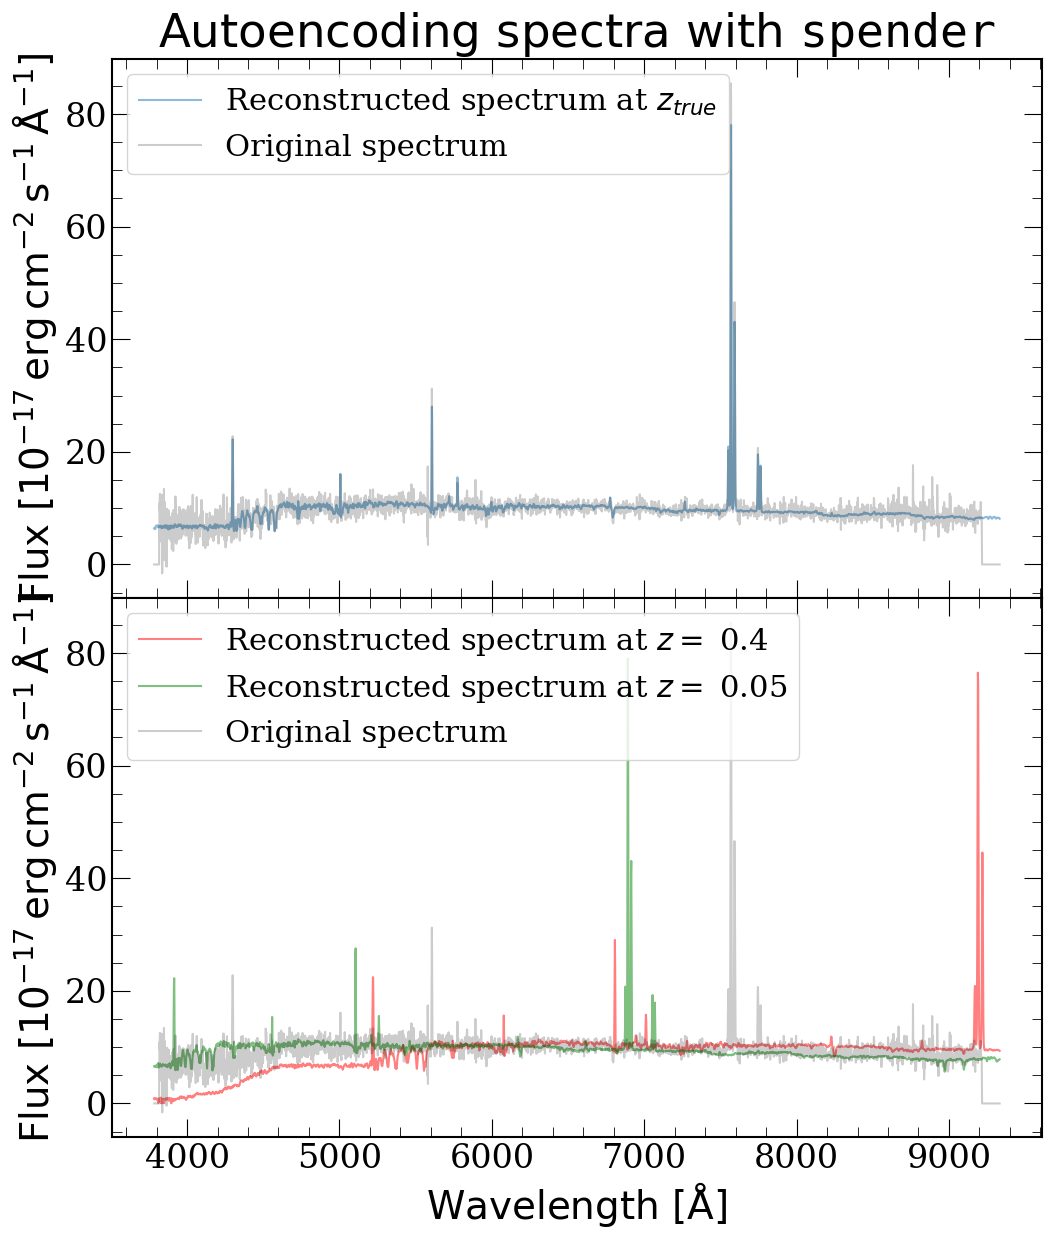

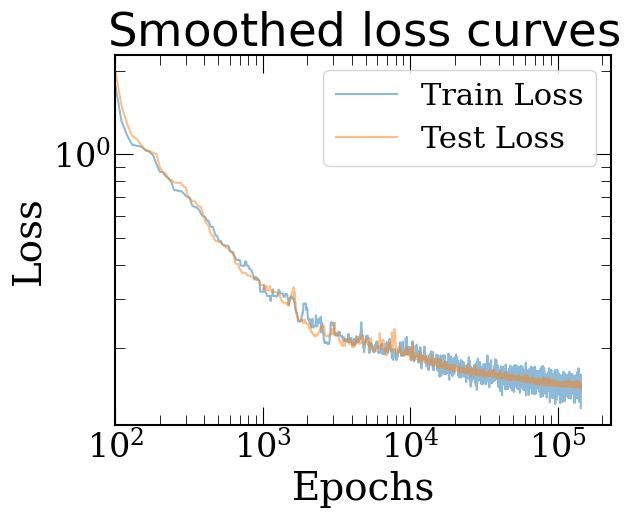

In [15]:
from scipy.signal import medfilt

smoothing = 21
fig, ax = plt.subplots()
epochs = np.arange(len(train_loss))*10
ax.plot(epochs, medfilt(train_loss, smoothing), alpha = 0.5, label = 'Train Loss')
plt.plot(epochs, medfilt(test_loss, smoothing), alpha = 0.5, label = 'Test Loss')

ax.set(yscale='log', xscale='log', xlim = (100, None), title = r'$\mathrm{Smoothed~loss~curves}$', ylabel = 'Loss', xlabel = 'Epochs')
ax.legend()
plt.show()

# Old code with data loader

In [18]:
#################################################
### let's get the predictions on the test set ###
#################################################
y_test, pred_test, sig_test = [], [], []
for data in test_loader:
    model.eval()
    out = model(data[0])
    pred_test.append(out.cpu().detach().numpy())
    y_test.append(data[1][:,:4].cpu().detach().numpy())    
    sig_test.append(data[1][:,4:].cpu().detach().numpy())
    
y_test, y_pred, sig_test = np.vstack(y_test), np.vstack(pred_test), np.vstack(sig_test)

NameError: name 'test_loader' is not defined

# New code without data loader

In [16]:
model.eval()
with torch.no_grad():
    pred_tensor = model(X_test)   # (N_test, 4) — MLP predictions on GPU

y_pred    = pred_tensor.cpu().numpy()          # (N_test, 4) — MLP predictions
y_test    = Y_test.cpu().numpy()               # (N_test, 4) — true WISE magnitudes
#sig_test  = (V_test ** 2).cpu().numpy()        # (N_test, 4) — raw sigmpro values
sig_test  = (V_test).cpu().numpy()        # (N_test, 4) — raw sigmpro values, without square

model.train()  # restore train mode for any subsequent training

Sequential(
  (0): Linear(in_features=8, out_features=20, bias=True)
  (1): ReLU()
  (2): Linear(in_features=20, out_features=50, bias=True)
  (3): ReLU()
  (4): Linear(in_features=50, out_features=50, bias=True)
  (5): ReLU()
  (6): Linear(in_features=50, out_features=20, bias=True)
  (7): ReLU()
  (8): Linear(in_features=20, out_features=4, bias=True)
)

In [17]:
sig_test[100]

array([ 0.19748418,  0.2915476 ,  0.40987802, 99.995     ], dtype=float32)

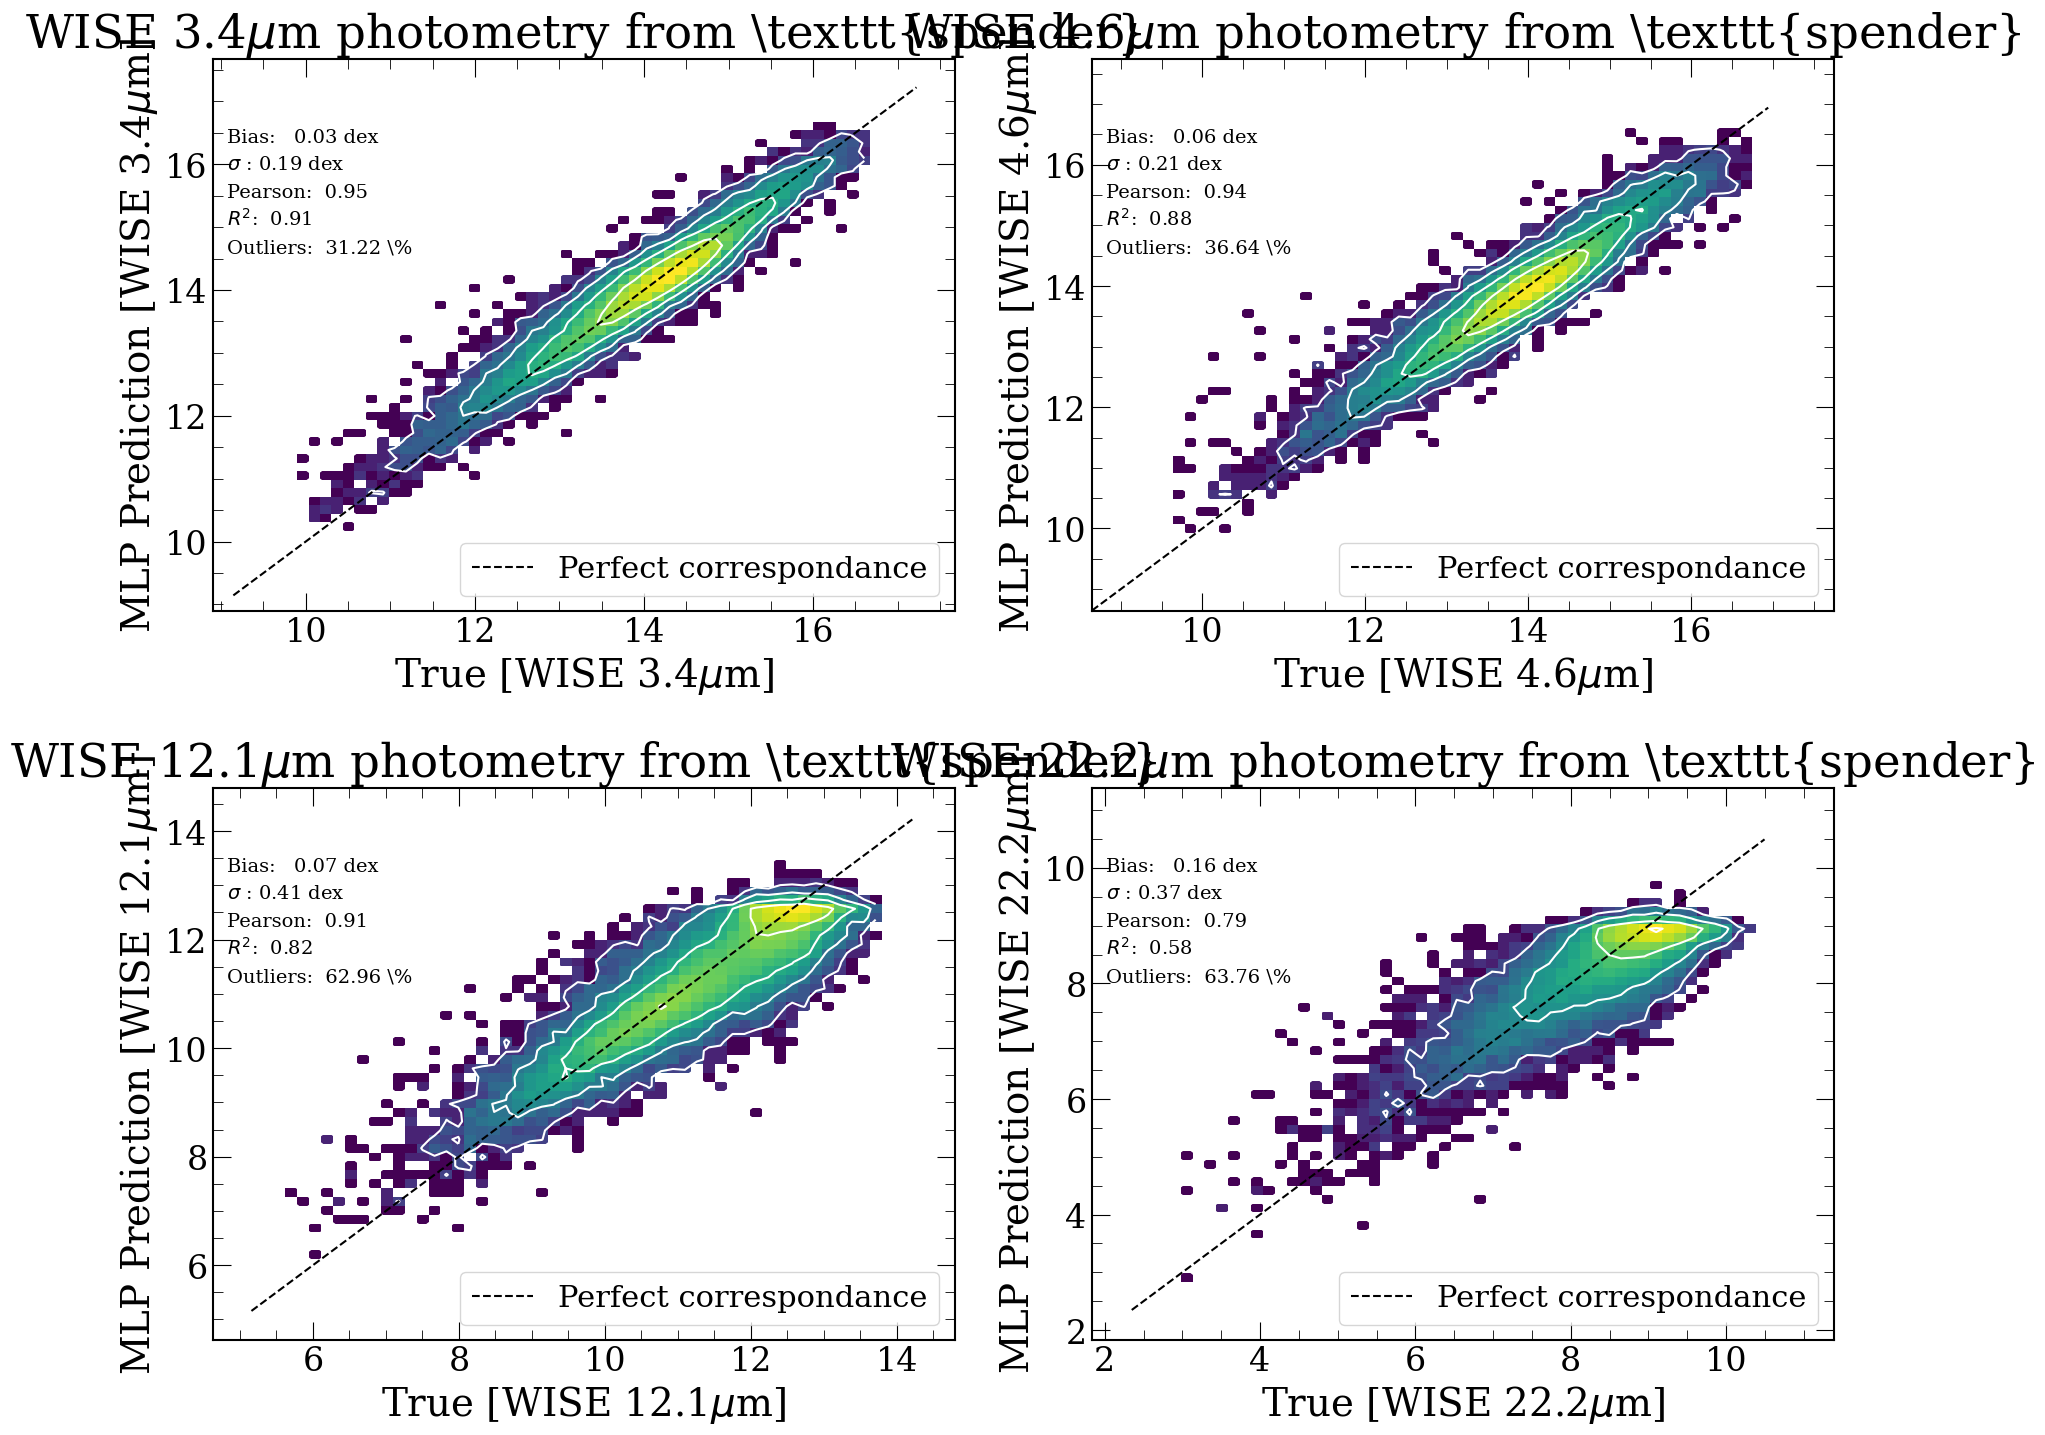

In [18]:
##################################
### let's plot our predictions ###
##################################

from sklearn.metrics import r2_score
fig, axs = plt.subplots(2, 2, figsize = (18, 15))

axs = axs.flatten()

for i in range(4):
    
    ax = axs[i]
    bins = 50
    l = 0.01
    n_contour = 4

    pred, true = y_pred[:,i], y_test[:,i]

    scatter = np.std(pred-true)
    bias = np.mean(true-pred)

    IQR = np.percentile(pred-true, [25, 75])
    scatter = (IQR[1] - IQR[0])/1.349
    bias = np.median(true-pred)

    pct = 1 - np.sum(np.abs(true-pred)<0.2)/len(true-pred)    
    r2 = r2_score(true,pred)
    rho = np.corrcoef(true,pred)[0,1]

    tot = np.hstack([true,pred])
    vals, x, y, hist = ax.hist2d(true, pred ,bins=bins, range=[np.percentile(tot, [0+l,100-l]),
                                        np.percentile(tot, [0+l,100-l])], norm=mpl.colors.LogNorm(),cmap=mpl.cm.viridis)

    names =  ['WISE 3.4$\mu$m', 'WISE 4.6$\mu$m', 'WISE 12.1$\mu$m', 'WISE 22.2$\mu$m']
    ax.set(ylabel = r'MLP Prediction '+ f'[{names[i]}]',\
           xlabel = r'True '+ f'[{names[i]}]', title = f'{names[i]}'+r' photometry from \texttt{spender}')
    l = np.percentile(tot, [0+l,100-l]) + np.array([-1, 1])
    ax.set(xlim = l, ylim = l)

    X, Y = np.meshgrid((x[1:]+x[:-1])/2, (y[1:]+y[:-1])/2)
    ax.contour(X,Y, np.log(vals.T+1), levels=n_contour, colors='white'),
    ax.plot([min(true), max(true)],[min(true), max(true)], 'k--', label='Perfect correspondance')

    xt=0.02
    yt=0.85
    dy=0.05
    font = {'weight': 'normal', 'size': 14}

    ax.text(xt,yt, f'Bias:   {bias:.2f} dex', fontdict=font, transform=ax.transAxes)
    ax.text(xt,yt-dy, r'$\sigma$ : '+f'{scatter:.2f} dex', fontdict=font, transform=ax.transAxes)
    ax.text(xt,yt-2*dy, r'Pearson:  '+f'{rho:.2f}', fontdict=font, transform=ax.transAxes)
    ax.text(xt,yt-3*dy, r'$R^2$:  '+f'{r2:.2f}', fontdict=font, transform=ax.transAxes)
    ax.text(xt,yt-4*dy, r'Outliers:  '+f'{pct*100:.2f} \%', fontdict=font, transform=ax.transAxes)

    ax.legend(loc = 'lower right')
fig.tight_layout()
plt.show()

In [19]:
def IQR_sig(x):
    iqr = np.nanpercentile(x, [84, 16])
    return (iqr[0]-iqr[1])/2

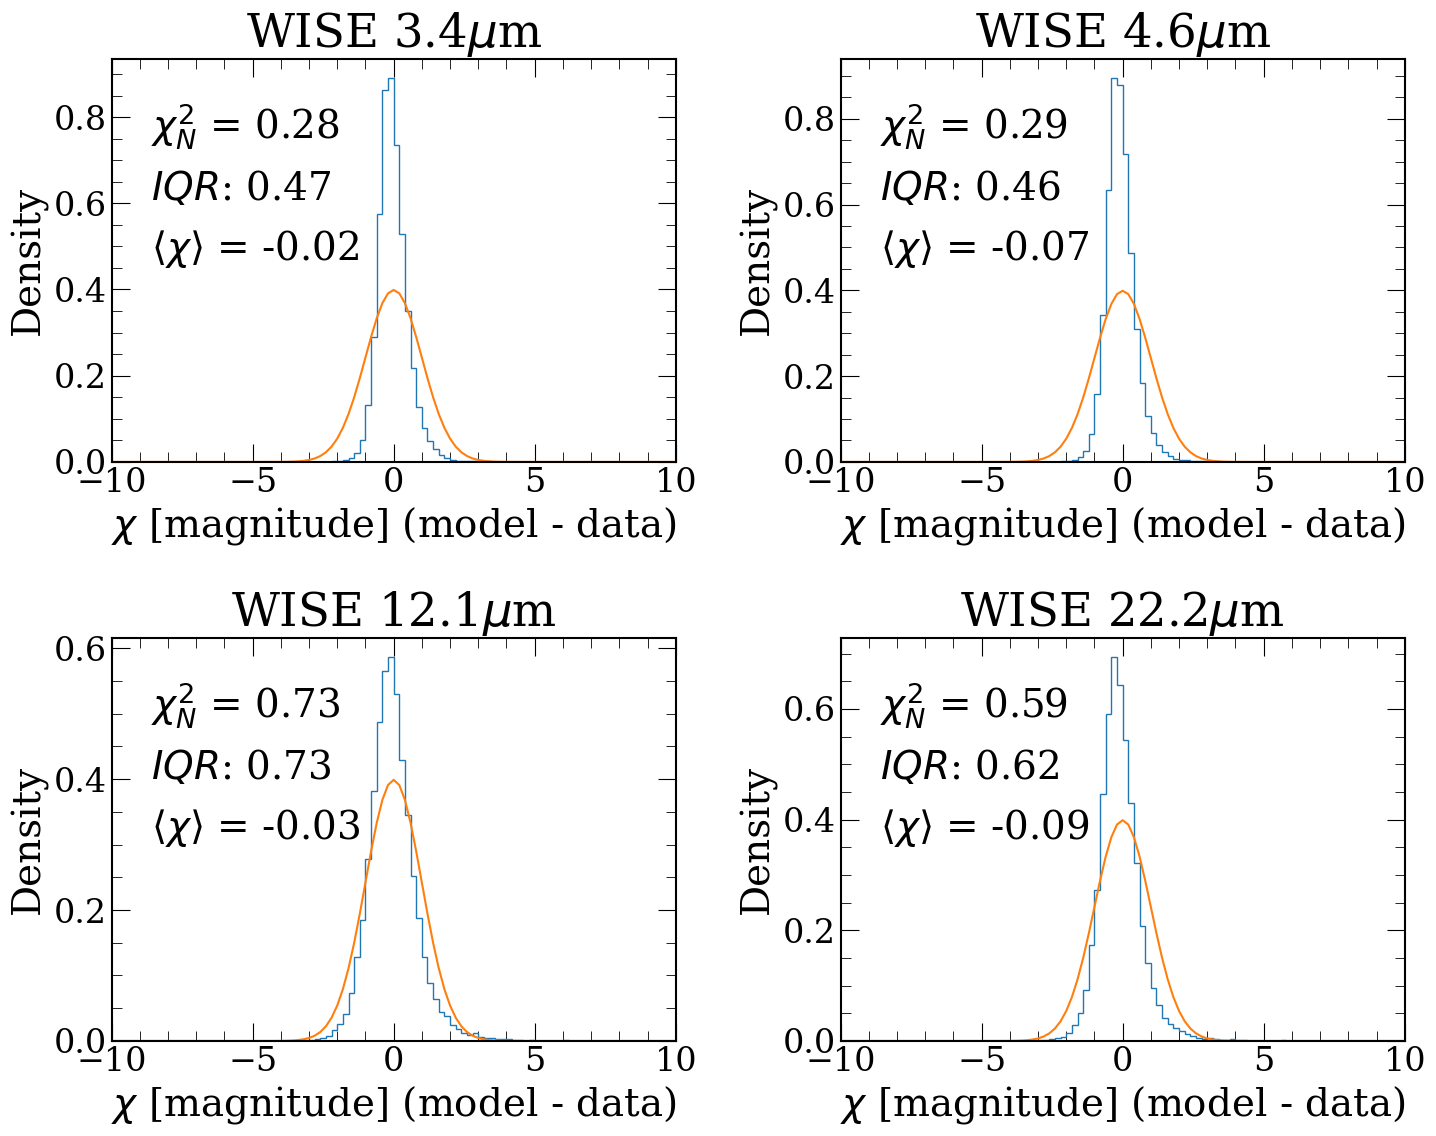

In [20]:
fig, axs = plt.subplots(2, 2, figsize = (15, 12))
axs = axs.flatten()
xt = 0.07
yt = 0.8
dy = 0.15

outlier_lim = 100
for i in range(4):
    pred, true = y_pred[:,i], y_test[:,i]
    m = sig_test[:,i]<5 #select only bands with detections
    z = (pred[m]-true[m])/np.sqrt(sig_test[m,i]) # better chi-square, worse looking
    #z = (pred[m]-true[m])/sig_test[m,i] # better looking, worse Chi-square
    vals, bins, _ = axs[i].hist( z, bins = 100, range = (-10, 10), histtype = 'step', density = 1);
    axs[i].set( xlim = (-10, 10), xlabel = r'$\chi$ [magnitude] (model - data)', ylabel = 'Density', title = names[i])
    axs[i].plot(bins, 1/np.sqrt(2*np.pi)*np.exp(-bins**2/2))
    axs[i].text(xt, yt, fr'$\chi^2_N$ = {sum(z[z<outlier_lim]**2)/len(z[z<outlier_lim]):.2f}', transform=axs[i].transAxes)
    axs[i].text(xt, yt-dy, fr'$IQR$: {IQR_sig(z):.2f}', transform=axs[i].transAxes)
    axs[i].text(xt, yt-2*dy, fr'$\langle \chi \rangle$ = {np.mean(z):.2f}', transform=axs[i].transAxes)
    
fig.tight_layout()
plt.show()

As you should be able to see, the distributions are already getting close to $\chi^2_N \approx 1$, especially in the centers, as measured by the IQR. This is much better than what spectrum fitting models can achieve!

If you include all the data, turn up the length of training, and do a couple of runs to make sure that you're not hitting a weird bump in the training for the final epoch, you should get to something even closer!

If you want to make sure that everything is reproducable, use the ``np.loadtxt('data/test_ids.csv').astype(int)`` as the test set.

## No matter what, congratulations on connecting the optical and the IR!

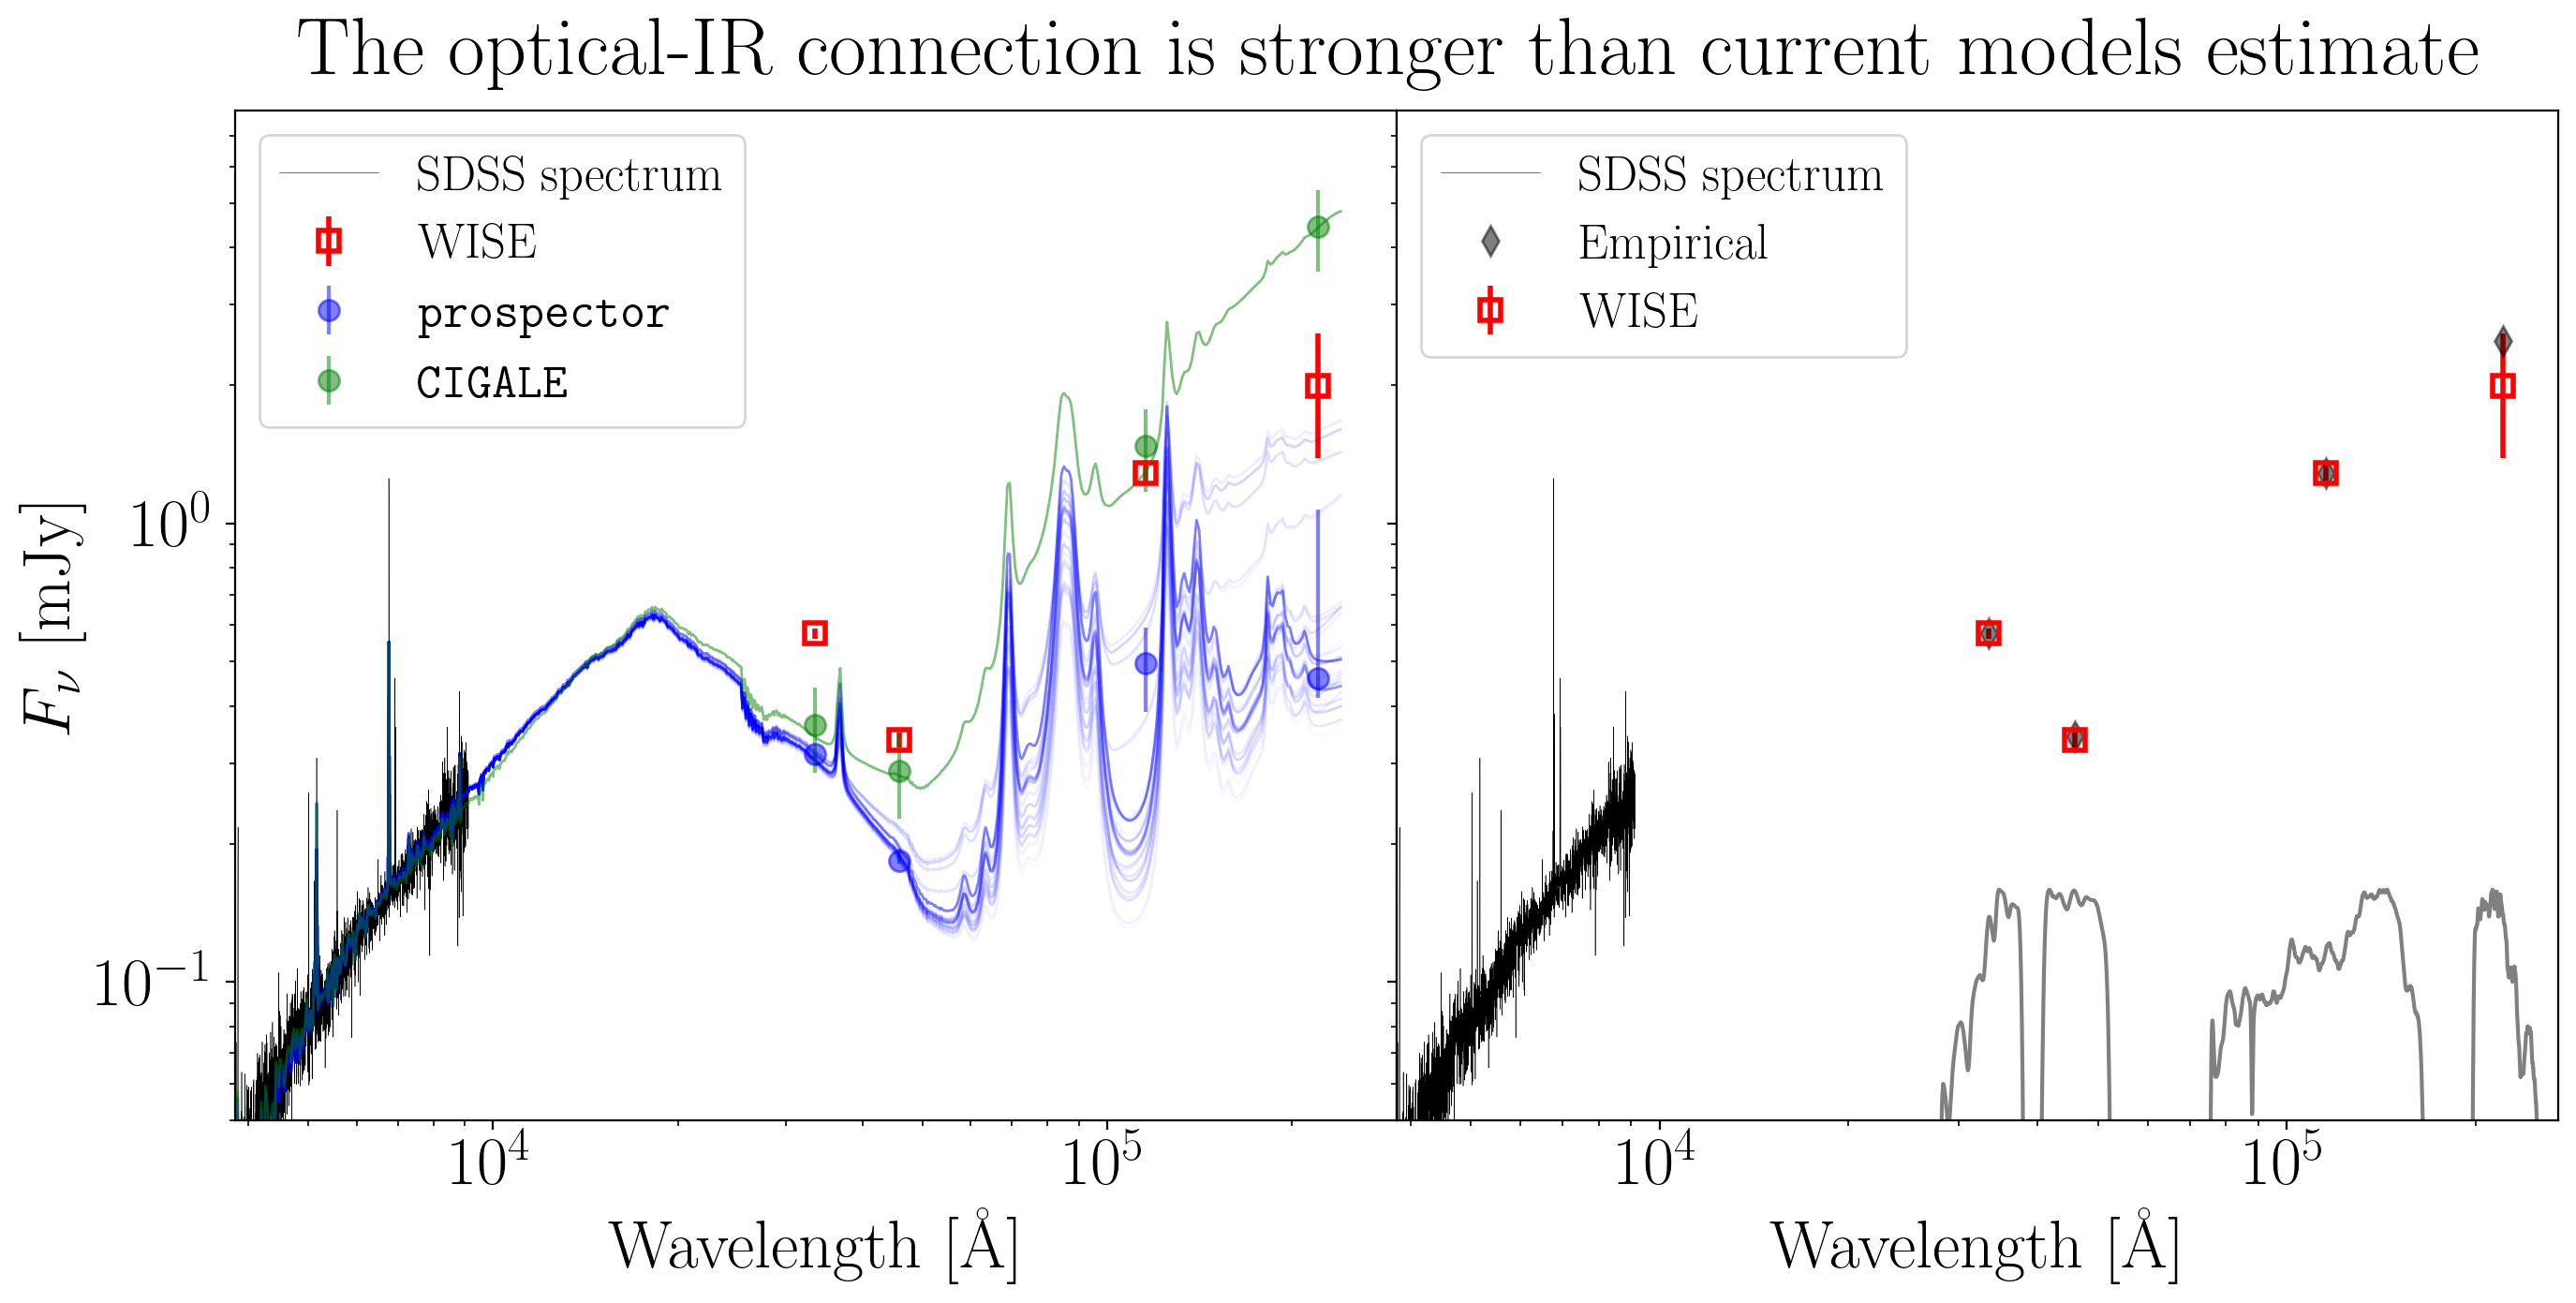

#### A little demonstration where we compare the emprical performance to the lackluster performance of two SED-fitting codes

# PP-plot, but using the formula from the paper

Band    <p̂_emp> ours  <p̂_emp> paper  <p̂_data> ours  <p̂_data> paper    N_det
──────────────────────────────────────────────────────────────────────────────
W1             0.8506            0.66          0.9582             0.70   50,428
W2             0.7757            0.70          0.8702             0.70   50,416
W3             0.5295            0.63          0.6902             0.70   37,124
W4             0.4659            0.70          0.5817             0.70   18,103


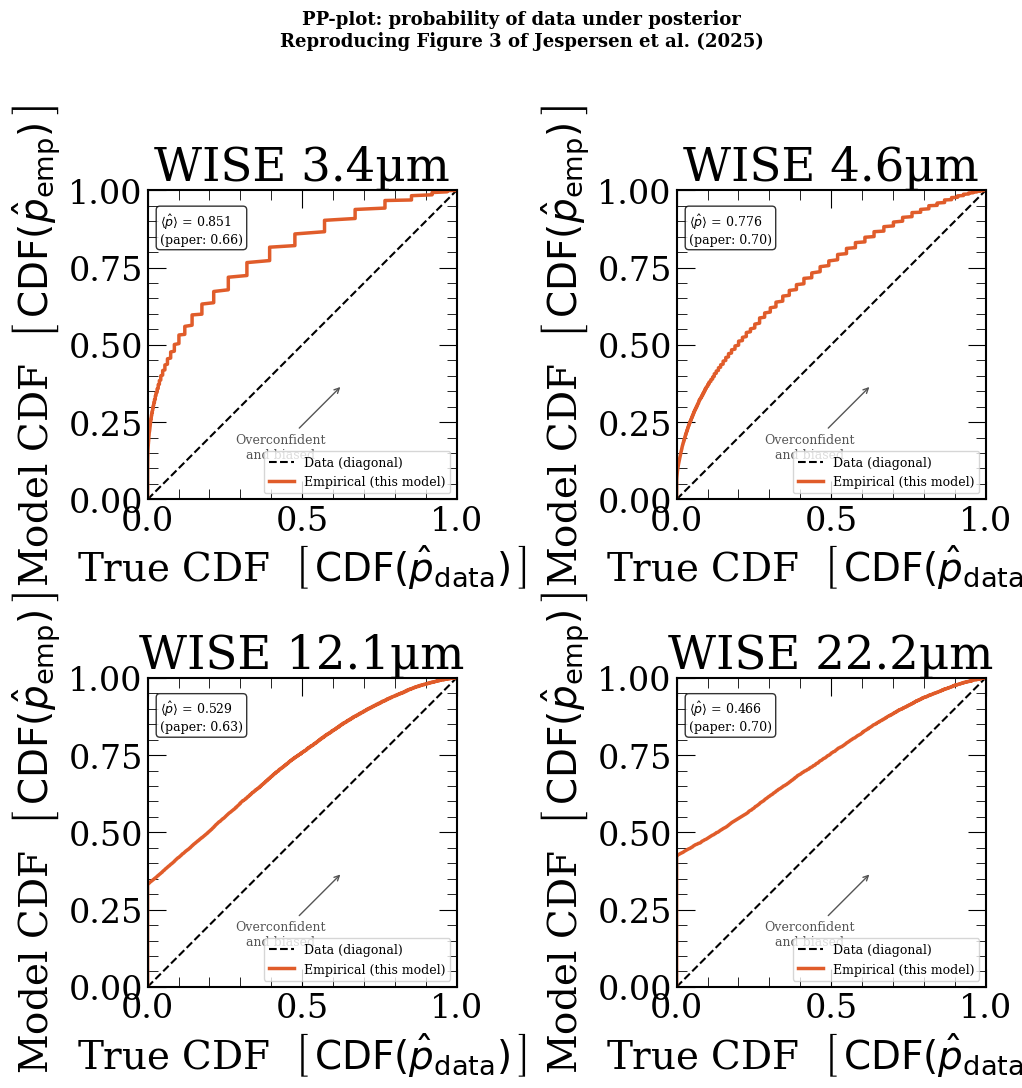

In [101]:
# ============================================================
#  PP-PLOT — Reproducing Figure 3 of Jespersen et al. (2025)
#  Following the exact formulation of Section 4 / Equations 2–3
# ============================================================
#
# ── Mathematical setup (for a math/CS reader new to astrophysics) ─────────────
#
# The paper defines a scalar summary of how well a model's posterior overlaps
# with the data.  In integral form (Equation 2):
#
#   p̂ = ∫ p_data(WISE) · p_model(WISE|optical) dWISE
#
# This is the expected likelihood of the data under the model posterior.
# Mathematically it's the inner product ⟨p_data, p_model⟩ in L²(dWISE).
#
# For OUR empirical MLP model, the posterior is a DELTA FUNCTION at the
# prediction ŷ_i (we output one point estimate, not a distribution).
# The integral then collapses trivially (Equation 3):
#
#   p̂_emp_i = p_data(ŷ_i)
#
# We approximate p_data as a Gaussian with the WISE measurement noise:
#
#   p_data(x) = N(x | y_obs, σ²)    where σ² = measurement variance
#
# So concretely:
#
#   p̂_emp_i = N(ŷ_i | y_obs_i, σ_i²)
#            = (1 / σ_i √2π) · exp(−(ŷ_i − y_obs_i)² / (2σ_i²))
#
# This is large when ŷ_i ≈ y_obs_i (good prediction) and small otherwise.
# Note: this is a probability DENSITY (not a probability), so it can exceed 1.
#
# ── The "Data" baseline ───────────────────────────────────────────────────────
#
# The paper also evaluates what the BEST POSSIBLE model would score: the data
# evaluated against itself.  When the model predicts ŷ_i = y_obs_i exactly,
# the residual is zero and we get the maximum of the Gaussian:
#
#   p̂_data_i = N(y_obs_i | y_obs_i, σ_i²) = 1 / (σ_i √2π)
#
# This only depends on σ_i (tighter measurement → larger maximum density).
# It varies galaxy-to-galaxy because WISE uncertainties vary.
#
# ── What the PP-plot shows ────────────────────────────────────────────────────
#
# We have two collections of scalars for N_test galaxies:
#   {p̂_data_i}   i=1..N   ← what a perfect model would score
#   {p̂_emp_i}    i=1..N   ← what our MLP actually scored
#
# We sweep a threshold t from 0 to ∞ and compute:
#   x(t) = (1/N) #{i : p̂_data_i ≤ t}   ← CDF of the "ideal" distribution
#   y(t) = (1/N) #{i : p̂_emp_i  ≤ t}   ← CDF of the "empirical" distribution
#
# Plotting y(t) vs x(t) as t varies gives Figure 3.
#
#   • If our model matches the ideal (ŷ ≈ y always) then p̂_emp ≈ p̂_data
#     and the curve lies ON the diagonal.
#   • If the curve lies ABOVE the diagonal (same x → more y already
#     accumulated) then low p̂_emp values are overrepresented, meaning
#     our model is WORSE than the ideal → overconfident/biased.
#   • The "Data" dashed diagonal is trivially x(t) = y(t) = CDF(p̂_data).
#
# ── Note on σ convention ──────────────────────────────────────────────────────
#
# In the demo notebook, `sig_test` stores the raw WISE `sigmpro` values.
# The training loss (GaussianNLLLoss) is called with torch.sqrt(sig_test),
# meaning the effective σ used throughout is sqrt(sigmpro), NOT sigmpro itself.
# We follow this same convention here for internal consistency.
# (This is a quirk of the demo notebook, not standard WISE convention.)
#
# ── Variables consumed from earlier cells ─────────────────────────────────────
#   y_test   : np.ndarray (N_test, 4) — true WISE Vega magnitudes
#   y_pred   : np.ndarray (N_test, 4) — MLP-predicted WISE Vega magnitudes
#   sig_test : np.ndarray (N_test, 4) — raw sigmpro values; σ = sqrt(sig_test)
#   names    : list of 4 strings      — band labels defined in cell 23
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm as scipy_norm

# ── 0. Band metadata ──────────────────────────────────────────────────────────
band_keys   = ['W1', 'W2', 'W3', 'W4']
# `names` was already defined in the notebook's cell 23, but we restate it
# here for self-containment so the cell can run standalone if needed.
names = ['WISE 3.4µm', 'WISE 4.6µm', 'WISE 12.1µm', 'WISE 22.2µm']

# These colors match Figure 3 of the paper (Empirical = red/orange curve)
color_emp  = '#e05c2a'   # red-orange: our empirical MLP model
color_data = 'k'         # black dashed: the "data under data" baseline

# ── 1. Maximum WISE uncertainty threshold for "detected" galaxies ─────────────
# WISE bands W3 and W4 are shallower; many galaxies are undetected there.
# Un-detected sources get artificially large sigmpro values (≥ 5 mag in the
# paper's convention, or effectively ∞).  We restrict to detections only,
# consistent with Section 4: "all results concern only data points with
# detections in any given band."
SIGMA_MAX_RAW = 5.0    # threshold on raw sigmpro (before sqrt)

# ── 2. Paper's Table 4 reference values ──────────────────────────────────────
# These are the mean p̂ values reported in the paper's Table 4.
# We print our computed means alongside for comparison.
paper_mean_emp  = {'W1': 0.66, 'W2': 0.70, 'W3': 0.63, 'W4': 0.70}
paper_mean_data = {'W1': 0.70, 'W2': 0.70, 'W3': 0.70, 'W4': 0.70}

# ── 3. Compute p̂_emp and p̂_data for each band ───────────────────────────────
print(f"{'Band':<6} {'<p̂_emp> ours':>14} {'<p̂_emp> paper':>15} "
      f"{'<p̂_data> ours':>15} {'<p̂_data> paper':>16} {'N_det':>8}")
print('─' * 78)

phat_emp  = {}   # dict: band → array of p̂_emp_i values for detected galaxies
phat_data = {}   # dict: band → array of p̂_data_i values for detected galaxies

for i, b in enumerate(band_keys):

    # ── 3a. Detection mask ────────────────────────────────────────────────────
    # Apply the same sig < 5 cut used throughout the notebook.
    # `sig_test[:, i]` are raw sigmpro values (before sqrt).
    detected = sig_test[:, i] < SIGMA_MAX_RAW
    N_det    = detected.sum()

    y_obs  = y_test[detected, i]   # observed WISE magnitude
    y_hat  = y_pred[detected, i]   # MLP-predicted WISE magnitude

    # ── 3b. σ convention: follow the demo notebook's training convention ──────
    # The loss was called as: loss_fn(out, targets, torch.sqrt(sig_test_batch))
    # GaussianNLLLoss expects `var` (variance) as its 3rd argument.
    # So the "variance" used in training = sqrt(sigmpro), meaning the
    # effective σ (std dev) = (sigmpro)^(1/4)... but more practically,
    # we just match whatever σ the notebook uses in its pp-plot cell, which is
    # sigma = np.sqrt(sig_test[detected, i]).
    sigma = np.sqrt(sig_test[detected, i])    # effective σ for each galaxy
    #sigma = sig_test[detected, i] # verified that this is worse
    
    # ── 3c. p̂_emp_i = N(ŷ_i | y_obs_i, σ_i²) ───────────────────────────────
    # This is the Gaussian PDF of the prediction ŷ_i under the noise model
    # centered at the observation y_obs_i.
    # scipy_norm.pdf(x, loc=μ, scale=σ) = (1/σ√2π) exp(−(x−μ)²/2σ²)
    phat_emp[b]  = scipy_norm.pdf(y_hat, loc=y_obs, scale=sigma)

    # ── 3d. p̂_data_i = N(y_obs_i | y_obs_i, σ_i²) = 1/(σ_i √2π) ───────────
    # The maximum achievable likelihood: residual = 0, so we hit the peak
    # of the Gaussian.  Only depends on σ_i (not on the prediction).
    phat_data[b] = scipy_norm.pdf(0.0, loc=0.0, scale=sigma)

    print(f"{b:<6} {np.mean(phat_emp[b]):>14.4f} {paper_mean_emp[b]:>15.2f} "
          f"{np.mean(phat_data[b]):>15.4f} {paper_mean_data[b]:>16.2f} {N_det:>8,d}")

# ── 4. Build the 2×2 PP-plot figure ──────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(11, 11))

for idx, b in enumerate(band_keys):
    ax = axes[idx // 2, idx % 2]

    if b not in phat_emp:
        # Shouldn't happen, but guard gracefully
        ax.text(0.5, 0.5, f'No detections for {b}',
                transform=ax.transAxes, ha='center', va='center')
        ax.set_title(names[idx])
        continue

    pe = phat_emp[b]    # array of p̂_emp_i values  (shape: N_det,)
    pd = phat_data[b]   # array of p̂_data_i values (shape: N_det,)

    # ── 4a. Common threshold grid ─────────────────────────────────────────────
    # We need to evaluate BOTH CDFs at the SAME set of thresholds t.
    # Choose 2000 evenly-spaced points spanning [0, max of both distributions].
    # Using a dense grid ensures smooth curves.
    t_max      = max(pe.max(), pd.max())
    thresholds = np.linspace(0.0, t_max, 2000)

    # ── 4b. Evaluate both empirical CDFs at each threshold ───────────────────
    # np.searchsorted(arr_sorted, t) gives the number of elements ≤ t when
    # arr_sorted is sorted.  Dividing by N gives the empirical CDF value.
    pe_sorted = np.sort(pe)    # sort once for efficient searchsorted
    pd_sorted = np.sort(pd)    # sort once for efficient searchsorted
    N         = len(pe)

    # CDF(p̂_data)(t)  — the x-axis of Figure 3 ("True CDF")
    cdf_data = np.searchsorted(pd_sorted, thresholds, side='right') / N

    # CDF(p̂_emp)(t)   — the y-axis of Figure 3 ("Model CDF")
    cdf_emp  = np.searchsorted(pe_sorted, thresholds, side='right') / N

    # ── 4c. Plot ──────────────────────────────────────────────────────────────
    # Diagonal: CDF_data vs CDF_data = identity line → "Data" baseline
    ax.plot([0, 1], [0, 1],
            color='k', linestyle='--', linewidth=1.5, label='Data (diagonal)')

    # Empirical model curve: x = CDF(p̂_data), y = CDF(p̂_emp)
    ax.plot(cdf_data, cdf_emp,
            color=color_emp, linewidth=2.5, label='Empirical (this model)')

    # ── 4d. "Overconfident and biased" annotation ─────────────────────────────
    # In Figure 3, curves ABOVE the diagonal indicate the model has more
    # low-probability predictions than the ideal (data vs data) case.
    # This arrow points toward the region above the diagonal.
    # Using axes-fraction coordinates avoids the aspect='equal' shift bug.
    ax.annotate('Overconfident\nand biased',
                xy=(0.63, 0.37),        # arrowhead location in axes coords
                xytext=(0.43, 0.17),    # text anchor in axes coords
                xycoords='axes fraction',
                textcoords='axes fraction',
                fontsize=9,
                color='#555555',
                ha='center',
                va='center',
                arrowprops=dict(arrowstyle='->', color='#555555', lw=1.0))

    # ── 4e. Mean p̂ annotation (matches Table 4) ───────────────────────────────
    # The paper's Table 4 reports ⟨p̂⟩ per band per model.
    # We annotate our computed mean on the plot for direct comparison.
    ax.text(0.04, 0.93,
            fr'$\langle\hat{{p}}\rangle$ = {np.mean(pe):.3f}'
            f'\n(paper: {paper_mean_emp[b]:.2f})',
            transform=ax.transAxes,
            fontsize=9,
            verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

    # ── 4f. Axis formatting ───────────────────────────────────────────────────
    ax.set(xlim=(0, 1),
           ylim=(0, 1),
           aspect='equal',
           xlabel=r'True CDF  $\left[\,\mathrm{CDF}(\hat{p}_\mathrm{data})\,\right]$',
           ylabel=r'Model CDF  $\left[\,\mathrm{CDF}(\hat{p}_\mathrm{emp})\,\right]$',
           title=names[idx])
    ax.legend(loc='lower right', fontsize=9)

# ── 5. Figure-level title and layout ─────────────────────────────────────────
fig.suptitle(
    'PP-plot: probability of data under posterior\n'
    r'Reproducing Figure 3 of Jespersen et al. (2025)',
    fontsize=13,
    fontweight='bold',
    y=1.01
)
fig.tight_layout()
plt.savefig('pp_plot_figure3_paper_faithful.pdf', bbox_inches='tight', dpi=150)
plt.show()

# MRE of PP-plot issue, with suggested fix from 3/19/26 suggestion

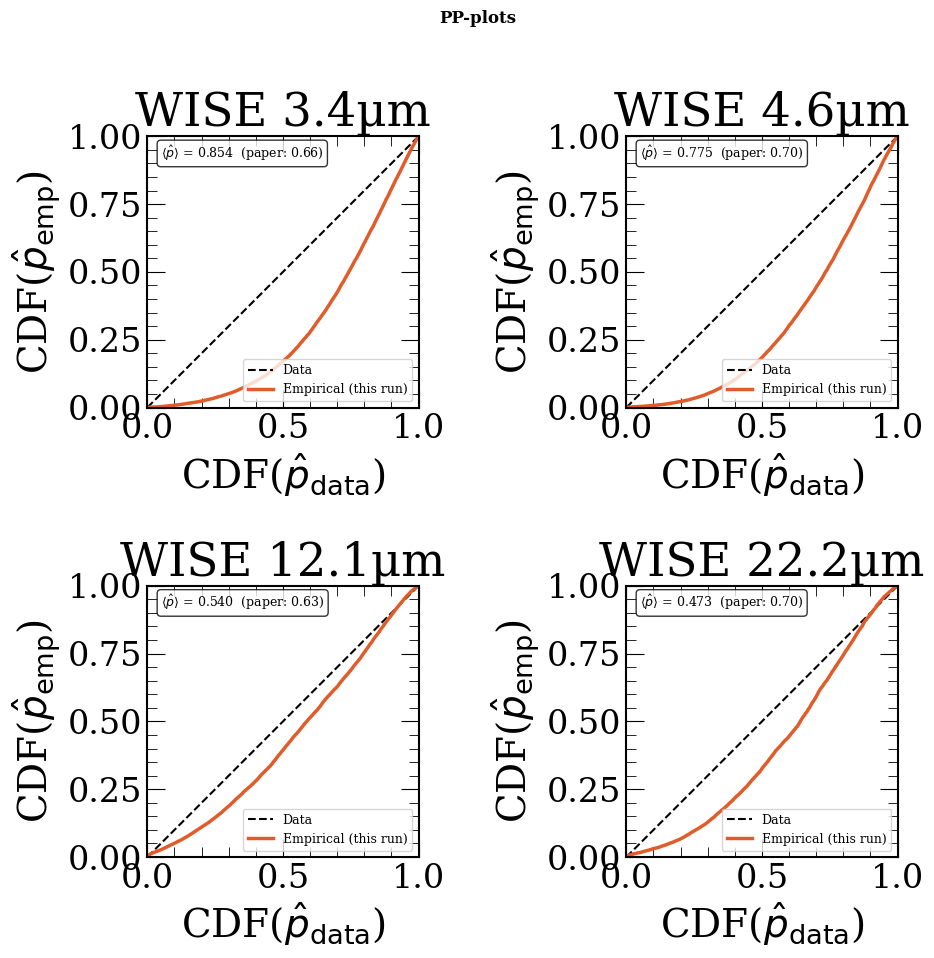

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm as scipy_norm
 
# Following Section 4 / Eq. 2-3 of Jespersen et al. (2025):
#   p̂_emp_i  = N(ŷ_i  | y_obs_i, σ_i²)  — likelihood of MLP prediction under WISE noise
#   p̂_data_i = N(y_obs_i | y_obs_i, σ_i²) = 1/(σ_i √2π)  — maximum achievable likelihood
# x-axis: CDF(p̂_data),  y-axis: CDF(p̂_emp),  diagonal = perfect calibration
 
names = ['WISE 3.4µm', 'WISE 4.6µm', 'WISE 12.1µm', 'WISE 22.2µm']
paper_mean = {'W1': 0.66, 'W2': 0.70, 'W3': 0.63, 'W4': 0.70}  # Table 4
 
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
 
for i, (b, ax) in enumerate(zip(['W1', 'W2', 'W3', 'W4'], axes.flatten())):
    det   = sig_test[:, i] < 5.0
    sigma = np.sqrt(sig_test[det, i])   # matches sqrt() used in training loss
 
    pe = scipy_norm.pdf(y_pred[det, i], loc=y_test[det, i], scale=sigma)  # p̂_emp
    #pd = scipy_norm.pdf(0.0,            loc=0.0,            scale=sigma)   # p̂_data
    p_data_pred = np.random.normal(loc=y_test[det, i], scale=sigma) 
    pd = scipy_norm.pdf(p_data_pred, loc=y_test[det, i], scale=sigma)   # p̂_dat
 
    thresholds = np.linspace(0.0, max(pe.max(), pd.max()), 2000)
    N          = len(pe)
    cdf_data   = np.searchsorted(np.sort(pd), thresholds, side='right') / N
    cdf_emp    = np.searchsorted(np.sort(pe), thresholds, side='right') / N
 
    ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Data')
    ax.plot(cdf_data, cdf_emp, color='#e05c2a', lw=2.5, label='Empirical (this run)')
    ax.set(xlim=(0,1), ylim=(0,1), aspect='equal',
           xlabel=r'CDF($\hat{p}_\mathrm{data}$)',
           ylabel=r'CDF($\hat{p}_\mathrm{emp}$)',
           title=names[i])
    ax.text(0.05, 0.92,
            fr'$\langle\hat{{p}}\rangle$ = {np.mean(pe):.3f}  (paper: {paper_mean[b]:.2f})',
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))
    ax.legend(loc='lower right', fontsize=9)
 
fig.suptitle('PP-plots',
             fontsize=12, fontweight='bold')
fig.tight_layout()
plt.show()

In [33]:
y_pred[det,i]

array([8.213565 , 8.133931 , 7.666031 , ..., 6.9079432, 9.105715 ,
       8.087586 ], shape=(18202,), dtype=float32)

In [34]:
p_data_pred

array([7.70632349, 7.30134836, 8.2398232 , ..., 7.52577935, 9.04795232,
       8.4780866 ], shape=(18202,))

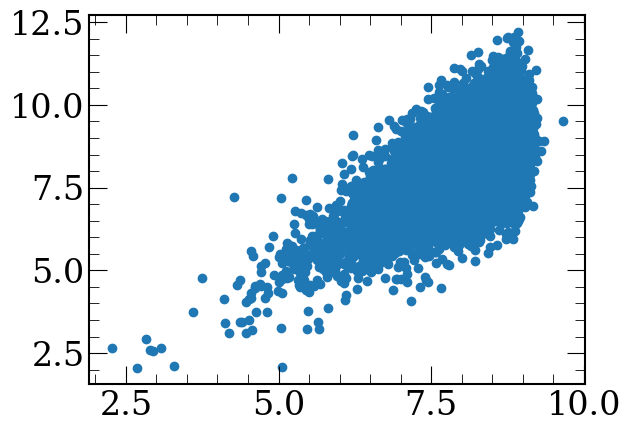

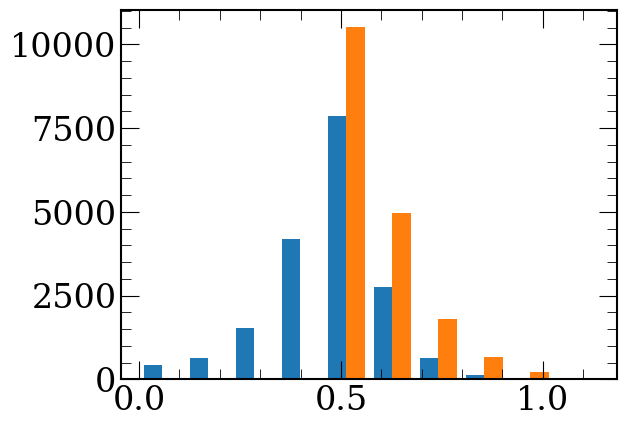

In [35]:
plt.figure()
plt.scatter(y_pred[det, i],p_data_pred)
plt.show()
plt.figure()
plt.hist([pe,pd], 10)
plt.show()

# Actual unedited MRE

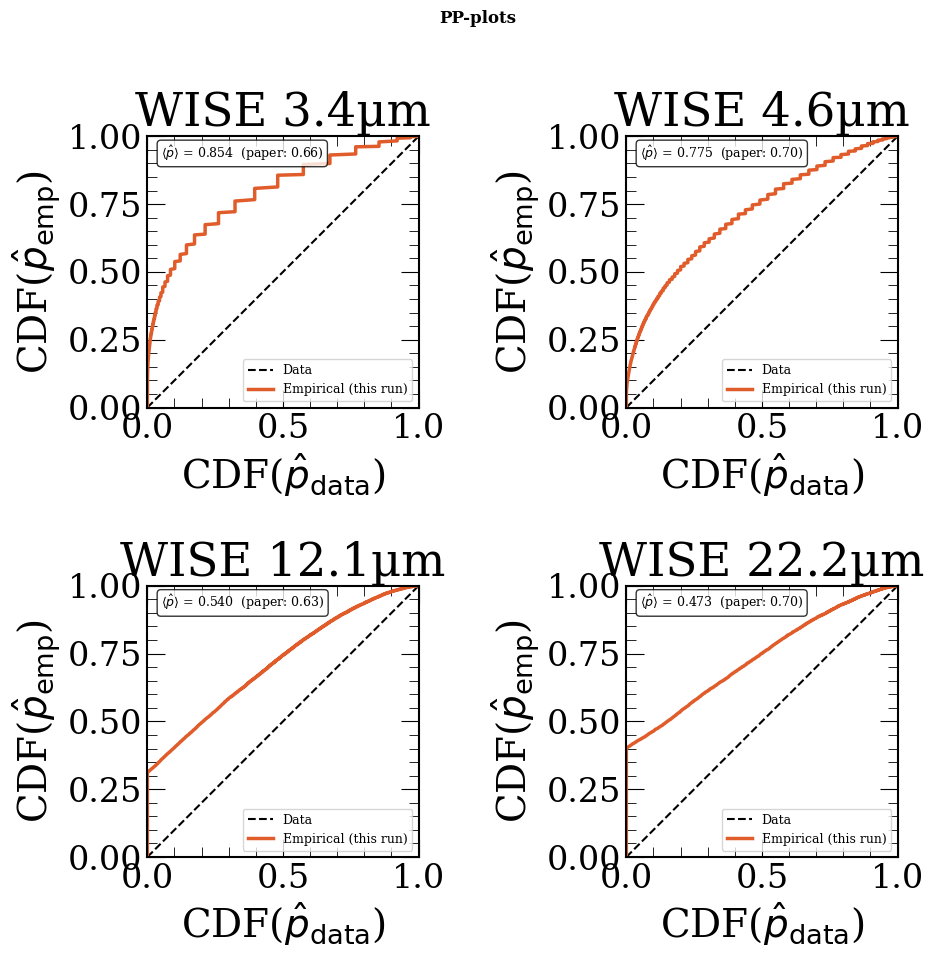

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm as scipy_norm
 
# Following Section 4 / Eq. 2-3 of Jespersen et al. (2025):
#   p̂_emp_i  = N(ŷ_i  | y_obs_i, σ_i²)  — likelihood of MLP prediction under WISE noise
#   p̂_data_i = N(y_obs_i | y_obs_i, σ_i²) = 1/(σ_i √2π)  — maximum achievable likelihood
# x-axis: CDF(p̂_data),  y-axis: CDF(p̂_emp),  diagonal = perfect calibration
 
names = ['WISE 3.4µm', 'WISE 4.6µm', 'WISE 12.1µm', 'WISE 22.2µm']
paper_mean = {'W1': 0.66, 'W2': 0.70, 'W3': 0.63, 'W4': 0.70}  # Table 4
 
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
 
for i, (b, ax) in enumerate(zip(['W1', 'W2', 'W3', 'W4'], axes.flatten())):
    det   = sig_test[:, i] < 5.0
    sigma = np.sqrt(sig_test[det, i])   # matches sqrt() used in training loss
 
    pe = scipy_norm.pdf(y_pred[det, i], loc=y_test[det, i], scale=sigma)  # p̂_emp
    pd = scipy_norm.pdf(0.0,            loc=0.0,            scale=sigma)   # p̂_data
 
    thresholds = np.linspace(0.0, max(pe.max(), pd.max()), 2000)
    N          = len(pe)
    cdf_data   = np.searchsorted(np.sort(pd), thresholds, side='right') / N
    cdf_emp    = np.searchsorted(np.sort(pe), thresholds, side='right') / N
 
    ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Data')
    ax.plot(cdf_data, cdf_emp, color='#e05c2a', lw=2.5, label='Empirical (this run)')
    ax.set(xlim=(0,1), ylim=(0,1), aspect='equal',
           xlabel=r'CDF($\hat{p}_\mathrm{data}$)',
           ylabel=r'CDF($\hat{p}_\mathrm{emp}$)',
           title=names[i])
    ax.text(0.05, 0.92,
            fr'$\langle\hat{{p}}\rangle$ = {np.mean(pe):.3f}  (paper: {paper_mean[b]:.2f})',
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))
    ax.legend(loc='lower right', fontsize=9)
 
fig.suptitle('PP-plots',
             fontsize=12, fontweight='bold')
fig.tight_layout()
plt.show()